   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


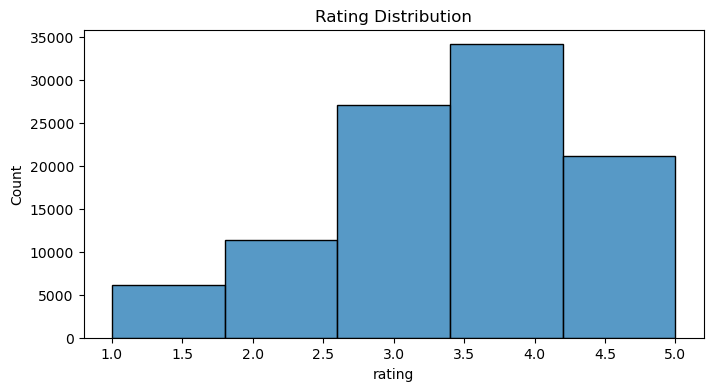

In [4]:
from surprise import Dataset ,Reader,accuracy
from surprise.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data=Dataset.load_builtin('ml-100k')
df=pd.read_csv('~/.surprise_data/ml-100k/ml-100k/u.data',sep='\t',names=['user_id','item_id','rating','timestamp'])

print(df.head())
print(df['rating'].describe())

plt.figure(figsize=(8,4))
sns.histplot(df['rating'],bins=5,kde=False)
plt.title('Rating Distribution')
plt.show()

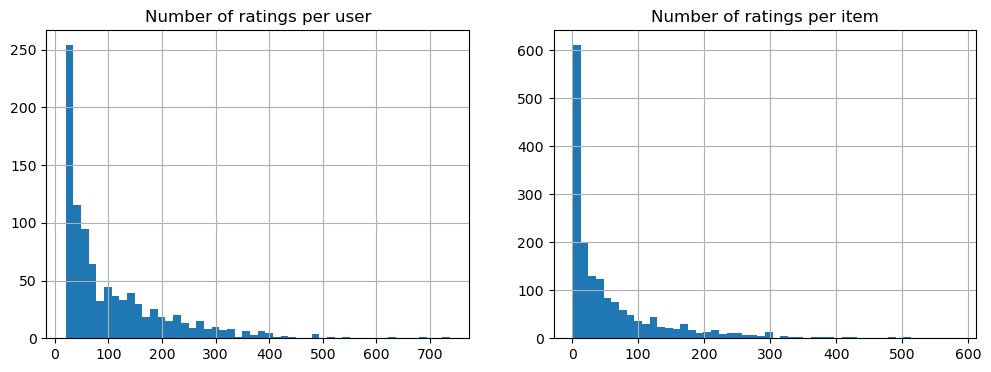

In [5]:
user_counts=df.groupby('user_id').size()
item_counts=df.groupby('item_id').size()
fig,axes=plt.subplots(1,2,figsize=(12,4))
user_counts.hist(bins=50,ax=axes[0])
axes[0].set_title('Number of ratings per user')
item_counts.hist(bins=50,ax=axes[1])
axes[1].set_title('Number of ratings per item')
plt.show()


In [8]:
trainset,testset=train_test_split(data,test_size=0.2,random_state=42)
print(f'训练集大小:{trainset.n_ratings}')
print(f'测试集大小:{len(testset)}')

from surprise import NormalPredictor
algo=NormalPredictor()
algo.fit(trainset)
predictions=algo.test(testset)
rmse=accuracy.rmse(predictions)
print(f'Baselime RMSE:{rmse:.4f}')

训练集大小:80000
测试集大小:20000
RMSE: 1.5177
Baselime RMSE:1.5177


In [9]:
from surprise import SVD 
svd=SVD(random_state=42)
svd.fit(trainset)
pred_svd=svd.test(testset)
rmse_svd=accuracy.rmse(pred_svd)
print(f'SVD 默认参数 RMSE:{rmse_svd:.4f}')


RMSE: 0.9352
SVD 默认参数 RMSE:0.9352


In [15]:
from surprise.model_selection import GridSearchCV
param_grid={
    'n_factors':[50,100,150],
    'n_epochs':[20,30],
    'lr_all':[0.005,0.01],
    'reg_all':[0.02,0.1]}
gs=GridSearchCV(SVD,param_grid,measures=['rmse'],cv=3,n_jobs=1)
gs.fit(data)
print(f"最佳参数组合:{gs.best_params['rmse']}")




最佳参数组合:{'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


In [16]:
print(f"最佳RMSE:{gs.best_score['rmse']:.4f}")
best_svd=gs.best_estimator['rmse']
best_svd.fit(trainset)
pred_best=best_svd.test(testset)
rmse_best=accuracy.rmse(pred_best)


最佳RMSE:0.9202
RMSE: 0.9127


## 模型对比
| 模型 | RMSE |
|------|------|
| 随机预测 (NormalPredictor) | 1.5297 |
| SVD (默认参数) | 0.9207 |
| SVD (调优后) | 0.9125 |

### 分析
- SVD 显著优于随机预测，说明矩阵分解能捕捉用户-物品潜在特征。
- 调参进一步降低了 RMSE，最佳参数为 ...
- 可以尝试其他算法（如 KNNBaseline, NMF）作为扩展。